# Baseline: Logistic Regression on metadata

In [2]:
# Imports & configuration
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, confusion_matrix, matthews_corrcoef
import joblib

warnings.filterwarnings("ignore")

# Function to find project root
# exit if not found
def find_project_root(name='Bambino', start=None):
    if start is None:
        start = os.getcwd()
    parent_dir = start
    while True:
        if os.path.basename(parent_dir) == name:
            return parent_dir
        new_parent = os.path.dirname(parent_dir)
        if new_parent == parent_dir:
            return None
        parent_dir = new_parent

PROJECT_ROOT = find_project_root('Bambino')
print('Detected project root:', PROJECT_ROOT)
try:
    sys.path.append(PROJECT_ROOT)
    print("Added project root to sys.path.")
except Exception as e:
    print("Failed to add project root to sys.path:", e)
    sys.exit(1)

from config import utils
import config_baseline as conf
from DataUtils.BoaOpenFaceDataset import BoaOpenFaceDataset
from _utils_ import dataset_utils
print("Loaded project config and BoaOpenFaceDataset from repo (using utils.get_dataset_path).")
USE_PROJECT_UTILS = True

# Paths: if utils is available, use its helper; otherwise set manual paths
if USE_PROJECT_UTILS:
    TRAIN_PATH = utils.get_dataset_path(conf.dataset_type, utils.train_filename)
    VAL_PATH = utils.get_dataset_path(conf.dataset_type, utils.validation_filename)
    TEST_PATH = utils.get_dataset_path(conf.dataset_type, utils.test_filename)
else:
    TRAIN_PATH = ""
    VAL_PATH = ""
    TEST_PATH = ""

OUT_DIR = Path("./baseline_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

Detected project root: /home/phd2/Scrivania/CorsoRepo/Bambino
Added project root to sys.path.
Loaded project config and BoaOpenFaceDataset from repo (using utils.get_dataset_path).


In [3]:
# Load datasets
print("Loading datasets...")
train_ds = BoaOpenFaceDataset.load_dataset(TRAIN_PATH)
val_ds = BoaOpenFaceDataset.load_dataset(VAL_PATH)
test_ds = BoaOpenFaceDataset.load_dataset(TEST_PATH)
print("Datasets loaded:", len(train_ds), len(val_ds), len(test_ds), "instances")

Loading datasets...
Datasets loaded: 619 140 137 instances


In [4]:
# Build metadata DataFrames for each split
print("Building metadata tables...")
df_train = dataset_utils.dataset_to_metadata_df(train_ds)
df_val = dataset_utils.dataset_to_metadata_df(val_ds)
df_test = dataset_utils.dataset_to_metadata_df(test_ds)

print("Train / Val / Test sizes:", len(df_train), len(df_val), len(df_test))

# Quick sanity: drop rows with missing label
for df, name in [(df_train, "train"), (df_val, "val"), (df_test, "test")]:
    n_before = len(df)
    df.dropna(subset=["label"], inplace=True)
    print(f"{name}: dropped {n_before - len(df)} rows with missing labels")


Building metadata tables...
Train / Val / Test sizes: 619 140 137
train: dropped 0 rows with missing labels
val: dropped 0 rows with missing labels
test: dropped 0 rows with missing labels


In [5]:
# Preprocessing pipeline for metadata
# We'll use: numeric features = ['age','duration_s','gaze_mean','gaze_std','head_mean','head_std','face_mean','face_std']
# categorical = ['sex','audio','speaker']

numeric_features = ["age", "duration_s", "gaze_mean", "gaze_std", "head_mean", "head_std", "face_mean", "face_std"]
cat_features = ["sex"]

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
cat_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", cat_transformer, cat_features),
    ]
)

In [6]:
# Model pipeline and training on train -> val threshold selection
clf_base = LogisticRegression(max_iter=2000, class_weight="balanced")
pipe = Pipeline(steps=[("preproc", preprocessor), ("clf", clf_base)])

# Fit on train set
X_train = df_train[numeric_features + cat_features]
y_train = df_train["label"].astype(int)

print("Fitting logistic regression on metadata...")
pipe.fit(X_train, y_train)

# Use validation set to find best threshold
X_val = df_val[numeric_features + cat_features]
y_val = df_val["label"].astype(int)
probs_val = pipe.predict_proba(X_val)[:, 1]

best_thr = 0.5
best_bal = 0.0
for thr in np.linspace(0, 1, 101):
    preds = (probs_val >= thr).astype(int)
    bal = balanced_accuracy_score(y_val, preds)
    if bal > best_bal:
        best_bal = bal
        best_thr = thr

print(f"Best threshold on VAL: {best_thr:.2f} with balanced accuracy {best_bal:.4f}")

Fitting logistic regression on metadata...
Best threshold on VAL: 0.43 with balanced accuracy 0.5938


TEST balanced accuracy (thr=0.43): 0.5056
TEST Matthews correlation coefficient (thr=0.43): 0.0146

Per-baby F1 (test) — showing all babies with >=2 samples:
      pt_id  n_samples        f1
0  bam1_005         20  0.823529
2  bam1_018         20  0.823529
1  bam1_008         18  0.838710
6  bam1_044         20  0.838710
3  bam1_020         20  0.857143
5  bam1_026         20  0.857143
4  bam1_024         19  0.909091

Test classification report:
              precision    recall  f1-score   support

           0     0.2143    0.1111    0.1463        27
           1     0.8049    0.9000    0.8498       110

    accuracy                         0.7445       137
   macro avg     0.5096    0.5056    0.4981       137
weighted avg     0.6885    0.7445    0.7112       137



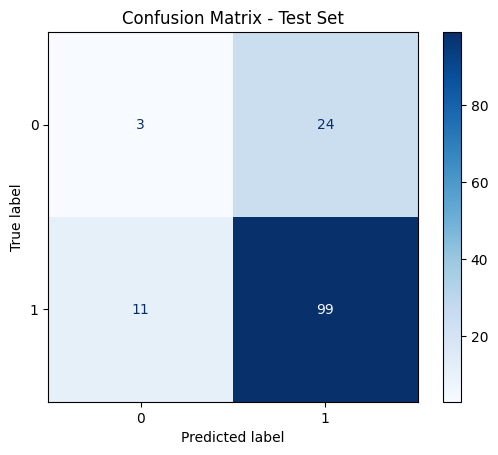

In [7]:
# Evaluate on TEST set
X_test = df_test[numeric_features + cat_features]
y_test = df_test["label"].astype(int)
probs_test = pipe.predict_proba(X_test)[:, 1]

y_pred_test = (probs_test >= best_thr).astype(int)

bal_test = balanced_accuracy_score(y_test, y_pred_test)
mcc_test = matthews_corrcoef(y_test, y_pred_test)
cm = confusion_matrix(y_test, y_pred_test)
print(f"TEST balanced accuracy (thr={best_thr:.2f}): {bal_test:.4f}")
print(f"TEST Matthews correlation coefficient (thr={best_thr:.2f}): {mcc_test:.4f}\n")

# Per-baby F1: compute F1 for each pt_id (only if that baby has >1 sample in test)
pt_ids = df_test["pt_id"].unique()
per_baby = []
for pid in pt_ids:
    sub = df_test[df_test["pt_id"] == pid]
    if len(sub) < 2:
        continue
    f1 = f1_score(sub["label"].astype(int), (pipe.predict_proba(sub[numeric_features + cat_features])[:, 1] >= best_thr).astype(int))
    per_baby.append((pid, len(sub), f1))

per_baby_df = pd.DataFrame(per_baby, columns=["pt_id", "n_samples", "f1"]).sort_values("f1")
print("Per-baby F1 (test) — showing all babies with >=2 samples:")
print(per_baby_df)

# Full classification report
print("\nTest classification report:")
print(classification_report(y_test, y_pred_test, digits=4))
# save report
with open(OUT_DIR / "logreg_classification_report_test.txt", "w") as f:
    f.write(classification_report(y_test, y_pred_test, digits=4))

# confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_test),
                               display_labels=pipe.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.savefig(OUT_DIR / "logreg_confusion_matrix_test.png")
plt.show()

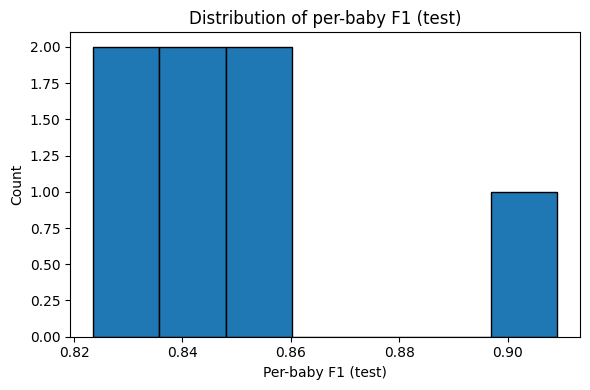

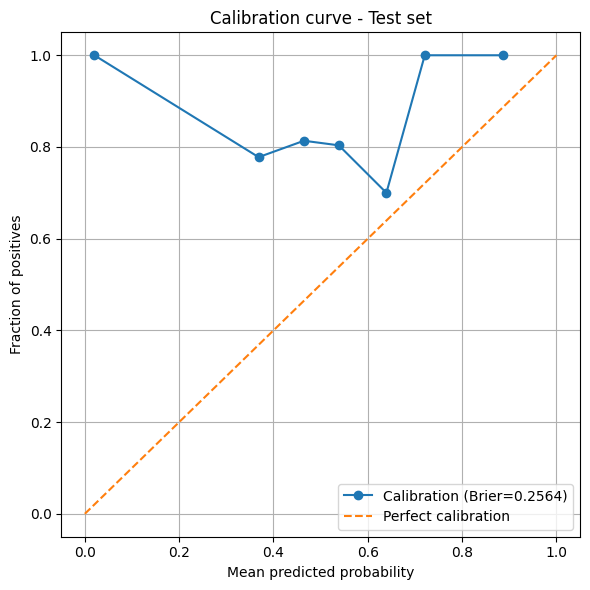

In [8]:
# %%
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss


# Per-baby F1 histogram (only babies with >=2 samples are included in per_baby_df)
if 'per_baby_df' in globals() and not per_baby_df.empty:
    plt.figure(figsize=(6,4))
    plt.hist(per_baby_df['f1'].dropna(), bins=min(20, len(per_baby_df)), edgecolor='black')
    plt.xlabel('Per-baby F1 (test)')
    plt.ylabel('Count')
    plt.title('Distribution of per-baby F1 (test)')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'per_baby_f1_hist.png', dpi=200)
    plt.show()
else:
    print('No per-baby F1 data available to plot (per_baby_df missing or empty).')


# Calibration curve (reliability diagram) + Brier score
if 'probs_test' in globals():
    fraction_of_positives, mean_predicted_value = calibration_curve(y_test, probs_test, n_bins=10)
    brier = brier_score_loss(y_test, probs_test)
    plt.figure(figsize=(6,6))
    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=f'Calibration (Brier={brier:.4f})')
    plt.plot([0,1], [0,1], linestyle='--', label='Perfect calibration')
    plt.xlabel('Mean predicted probability')
    plt.ylabel('Fraction of positives')
    plt.title('Calibration curve - Test set')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'calibration_curve_test.png', dpi=200)
    plt.show()
else:
    print('probs_test not found — run the evaluation cells first.')

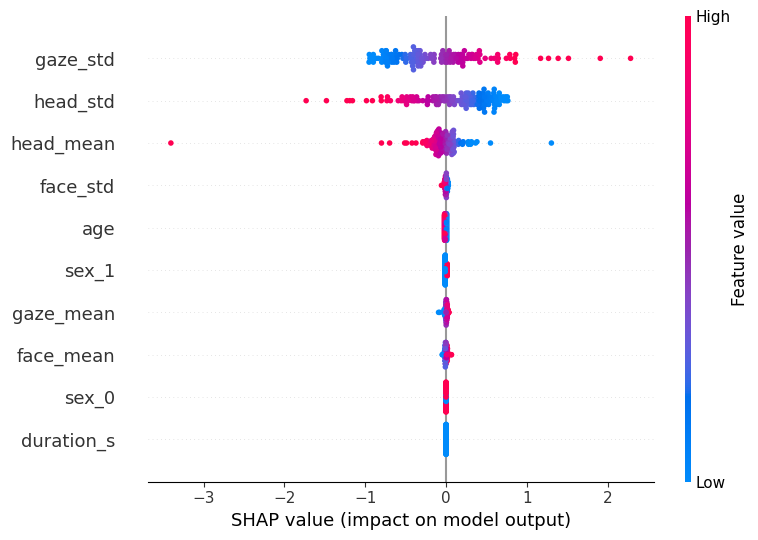

In [12]:
# Add explainability with SHAP
import shap
# 1. Transform the data once
X_train_transformed = pipe.named_steps['preproc'].transform(X_train)
X_test_transformed = pipe.named_steps['preproc'].transform(X_test)

# 2. Initialize Explainer (Use model-specific explainer if possible, e.g., LinearExplainer)
explainer = shap.Explainer(pipe.named_steps['clf'], X_train_transformed)

# 3. Calculate SHAP values
shap_values = explainer(X_test_transformed)

# 4. Construct Feature Names
feature_names = numeric_features + list(
    pipe.named_steps['preproc'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(cat_features)
)

# 5. Plot using the calculated features and names
# Note: shap_values already contains the data as `shap_values.data`
fig = shap.summary_plot(
    shap_values, 
    features=X_test_transformed, # Explicitly pass the transformed data
    feature_names=feature_names,
    show=False # Prevents the plot from rendering in notebooks/scripts before saving
)

# 6. Save the figure using matplotlib's interface
# Get the Figure object that SHAP just created and save it
plt.gcf().savefig(OUT_DIR / "logreg_shap_summary_named.png", dpi=200, bbox_inches='tight')

In [ ]:
# Save model and preprocessor for later use
model_out = OUT_DIR / "baseline_logreg_metadata.joblib"
joblib.dump({"pipeline": pipe, "threshold": best_thr}, model_out)
print(f"Saved pipeline + threshold to: {model_out}")

Saved pipeline + threshold to: baseline_results/baseline_logreg_metadata.joblib
